--- Optimization Results (50000 Evaluations | Pop Size: 50) ---
GD:  0.0344
IGD: 0.0090
HV:  9.3219
Pareto Points: 50/50000 (0.10%)
Generalized Spread (Lambda): 0.4286


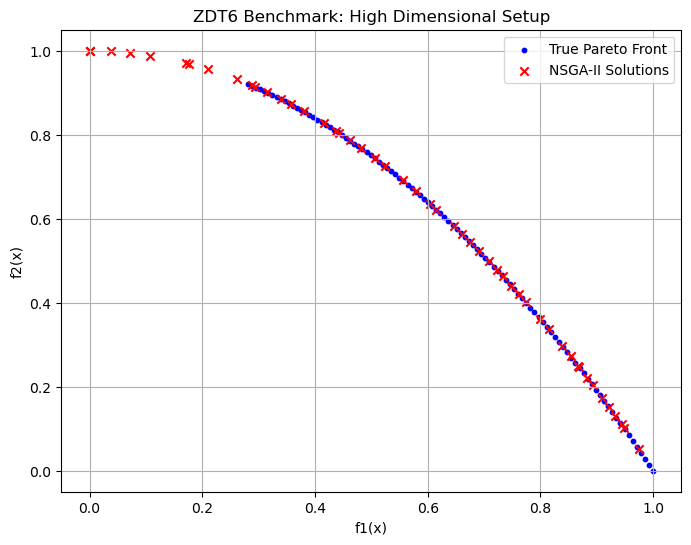

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.indicators.gd import GD
from pymoo.indicators.igd import IGD
from pymoo.indicators.hv import HV
from pymoo.problems import get_problem

# Experiment Parameters
pop_size = 50
n_gen = 1000
total_evals = pop_size * n_gen 

# ZDT6 Problem (10 Variables)
class ZDT6(Problem):
    def __init__(self):
        super().__init__(n_var=10, n_obj=2, xl=[0.0]*10, xu=[1.0]*10)

    def _evaluate(self, x, out, *args, **kwargs):
        # f1 calculation using only the first variable
        f1 = 1 - np.exp(-4 * x[:, 0] * np.sin(6 * np.pi * x[:, 0])**6)
        
        # g(x) calculation using the remaining 9 variables
        g = 1 + 9 * (np.sum(x[:, 1:], axis=1) / 9)**0.25
        
        # f2 calculation
        f2 = g * (1 - (f1 / g)**2)
        
        out["F"] = np.column_stack([f1, f2])

# Run NSGA-II
res = minimize(ZDT6(), NSGA2(pop_size=pop_size), ('n_gen', n_gen), seed=42, verbose=False)

# Fetch True Pareto Front directly from pymoo
pf_true = get_problem("zdt6").pareto_front()

# Quality Indicators and Visualization
if res.F is not None:
    print(f"--- Optimization Results ({total_evals} Evaluations | Pop Size: {pop_size}) ---")
    print(f"GD:  {GD(pf_true)(res.F):.4f}")
    print(f"IGD: {IGD(pf_true)(res.F):.4f}")
    print(f"HV:  {HV(ref_point=np.array([1.0, 10.0]))(res.F):.4f}")
    print(f"Pareto Points: {len(res.F)}/{total_evals} ({(len(res.F) / total_evals) * 100:.2f}%)")

    # Generalized Spread (Lambda) Calculation
    F = res.F
    if len(F) < 2:
        print("Generalized Spread (Lambda): N/A (insufficient Pareto points)")
    else:
        # Distance matrix between all obtained points
        D = cdist(F, F)
        np.fill_diagonal(D, np.inf) # Ignore distance to itself
        
        # Shortest distance from each point to its nearest neighbor
        d_i = np.min(D, axis=1)
        d_bar = d_i.mean()
        
        # Distance from the extreme true points to the obtained front
        E_true = pf_true[[np.argmin(pf_true[:, 0]), np.argmax(pf_true[:, 0])]]
        d_e = np.min(cdist(E_true, F), axis=1)
        
        # Lambda formula
        sum_d_e = np.sum(d_e)
        lambda_spread = (sum_d_e + np.sum(np.abs(d_i - d_bar))) / (sum_d_e + len(F) * d_bar)
        print(f"Generalized Spread (Lambda): {lambda_spread:.4f}")

    # Visualization
    plt.figure(figsize=(8, 6))
    plt.scatter(pf_true[:, 0], pf_true[:, 1], label="True Pareto Front", color="blue", s=10)
    plt.scatter(res.F[:, 0], res.F[:, 1], label="NSGA-II Solutions", color="red", marker="x")
    plt.title("ZDT6 Benchmark: High Dimensional Setup")
    plt.xlabel("f1(x)")
    plt.ylabel("f2(x)")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No feasible solutions found.")